# Visualizing .fig RIVER BASIN configurations

In [1]:
#pip install networkx matplotlib graphviz pydot

In [1]:
import networkx as nx
import pydot
from networkx.drawing.nx_pydot import graphviz_layout

G = nx.DiGraph()
G.add_edge("A", "B")
pos = graphviz_layout(G, prog="dot")


In [2]:
fig_orig_path = r"./original .fig/fig.fig"
fig_modi_path = r"./modified .fig/fig.fig"


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22204\1033517922.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


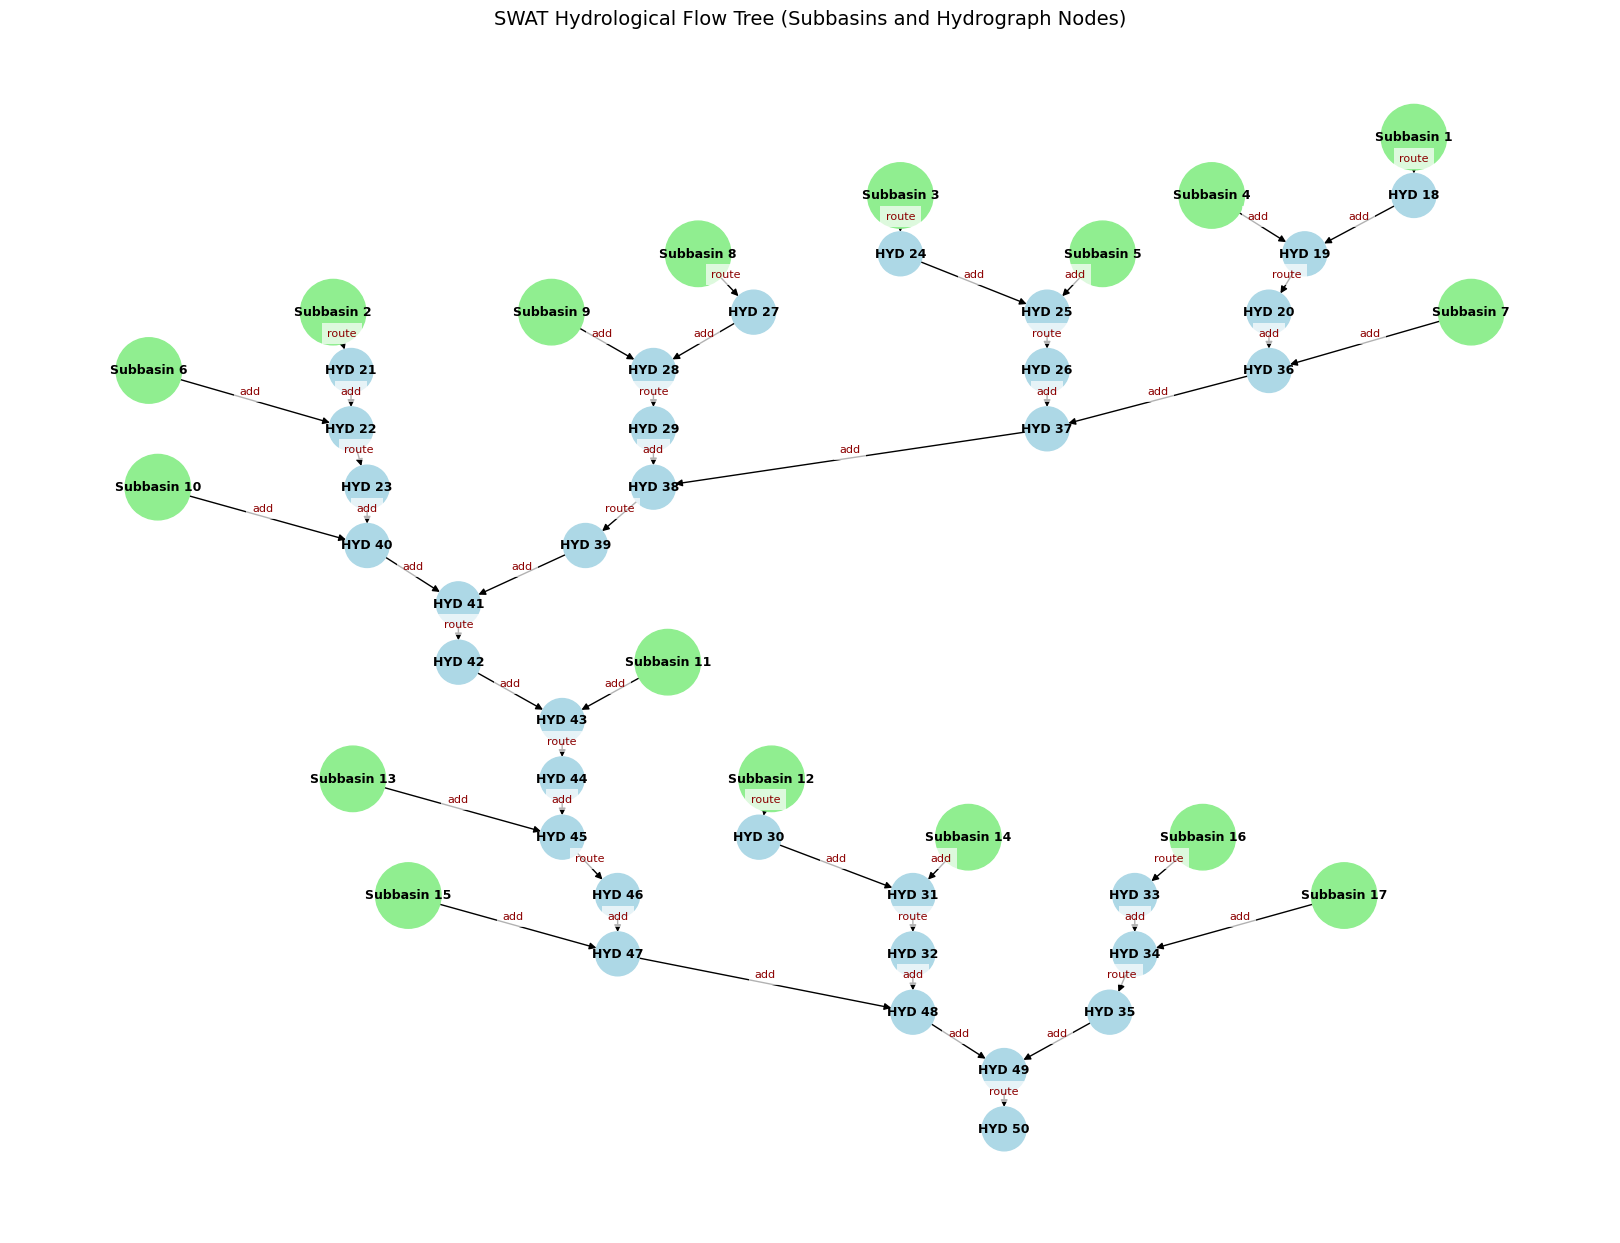

In [3]:
import matplotlib.pyplot as plt
import networkx as nx

fig_path = fig_orig_path  # Path to your .fig file

# --- Parse Commands ---
hyd_stor_to_subbasin = {}

routes = []
adds = []

with open(fig_path, 'r') as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i]
    if len(line) < 34:
        i += 1
        continue

    command = line[10:16].strip()

    if command == "1":  # SUBBASIN
        try:
            hyd_stor = int(line[16:22].strip())
            sub_num = int(line[22:28].strip())
            hyd_stor_to_subbasin[hyd_stor] = hyd_stor
        except ValueError:
            pass
        i += 2

    elif command == "2":  # ROUTE
        try:
            hyd_stor = int(line[16:22].strip())
            inflow = int(line[28:34].strip())
            routes.append((inflow, hyd_stor))
        except ValueError:
            pass
        i += 2

    elif command == "5":  # ADD
        try:
            out = int(line[16:22].strip())
            in1 = int(line[22:28].strip())
            in2 = int(line[28:34].strip())
            adds.append((in1, in2, out))
        except ValueError:
            pass
        i += 1
    else:
        i += 1

# --- Build Graph ---
G = nx.DiGraph()

all_nodes = set()
for inflow, outflow in routes:
    all_nodes.add(inflow)
    all_nodes.add(outflow)
for in1, in2, out in adds:
    all_nodes.update([in1, in2, out])
all_nodes.update(hyd_stor_to_subbasin.keys())

for node in all_nodes:
    label = f"Subbasin {hyd_stor_to_subbasin[node]}" if node in hyd_stor_to_subbasin else f"HYD {node}"
    color = 'lightgreen' if node in hyd_stor_to_subbasin else 'lightblue'
    size = 2220 if node in hyd_stor_to_subbasin else 1000
    G.add_node(node, size=size, label=label, color=color)

# Add edges
for inflow, outflow in routes:
    G.add_edge(inflow, outflow, type='route')
for in1, in2, out in adds:
    G.add_edge(in1, out, type='add')
    G.add_edge(in2, out, type='add')

# --- Layout ---
try:
    from networkx.drawing.nx_pydot import graphviz_layout
    pos = graphviz_layout(G, prog='dot')
except ImportError:
    print("Graphviz layout not available, falling back to spring layout.")
    pos = nx.spring_layout(G, seed=42)


nx.write_graphml(G, './original_fig_graph.graphml')

# --- Draw Graph ---
plt.figure(figsize=(16, 12))
node_colors = [G.nodes[n]['color'] for n in G.nodes]
labels = {n: G.nodes[n]['label'] for n in G.nodes}
edge_labels = {(u, v): G.edges[u, v]['type'] for u, v in G.edges()}

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, labels=labels,
        node_color=node_colors, 
        node_size = [G.nodes[n]['size'] for n in G.nodes], 
        font_size=9, 
        font_weight='bold'
    )
        

# Manual placement of edge labels
for (u, v), label in edge_labels.items():
    x = (pos[u][0] + pos[v][0]) / 2
    y = (pos[u][1] + pos[v][1]) / 2
    plt.text(x, y + 10, label, color='darkred', fontsize=8,
             ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

plt.title("SWAT Hydrological Flow Tree (Subbasins and Hydrograph Nodes)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22204\1625976941.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


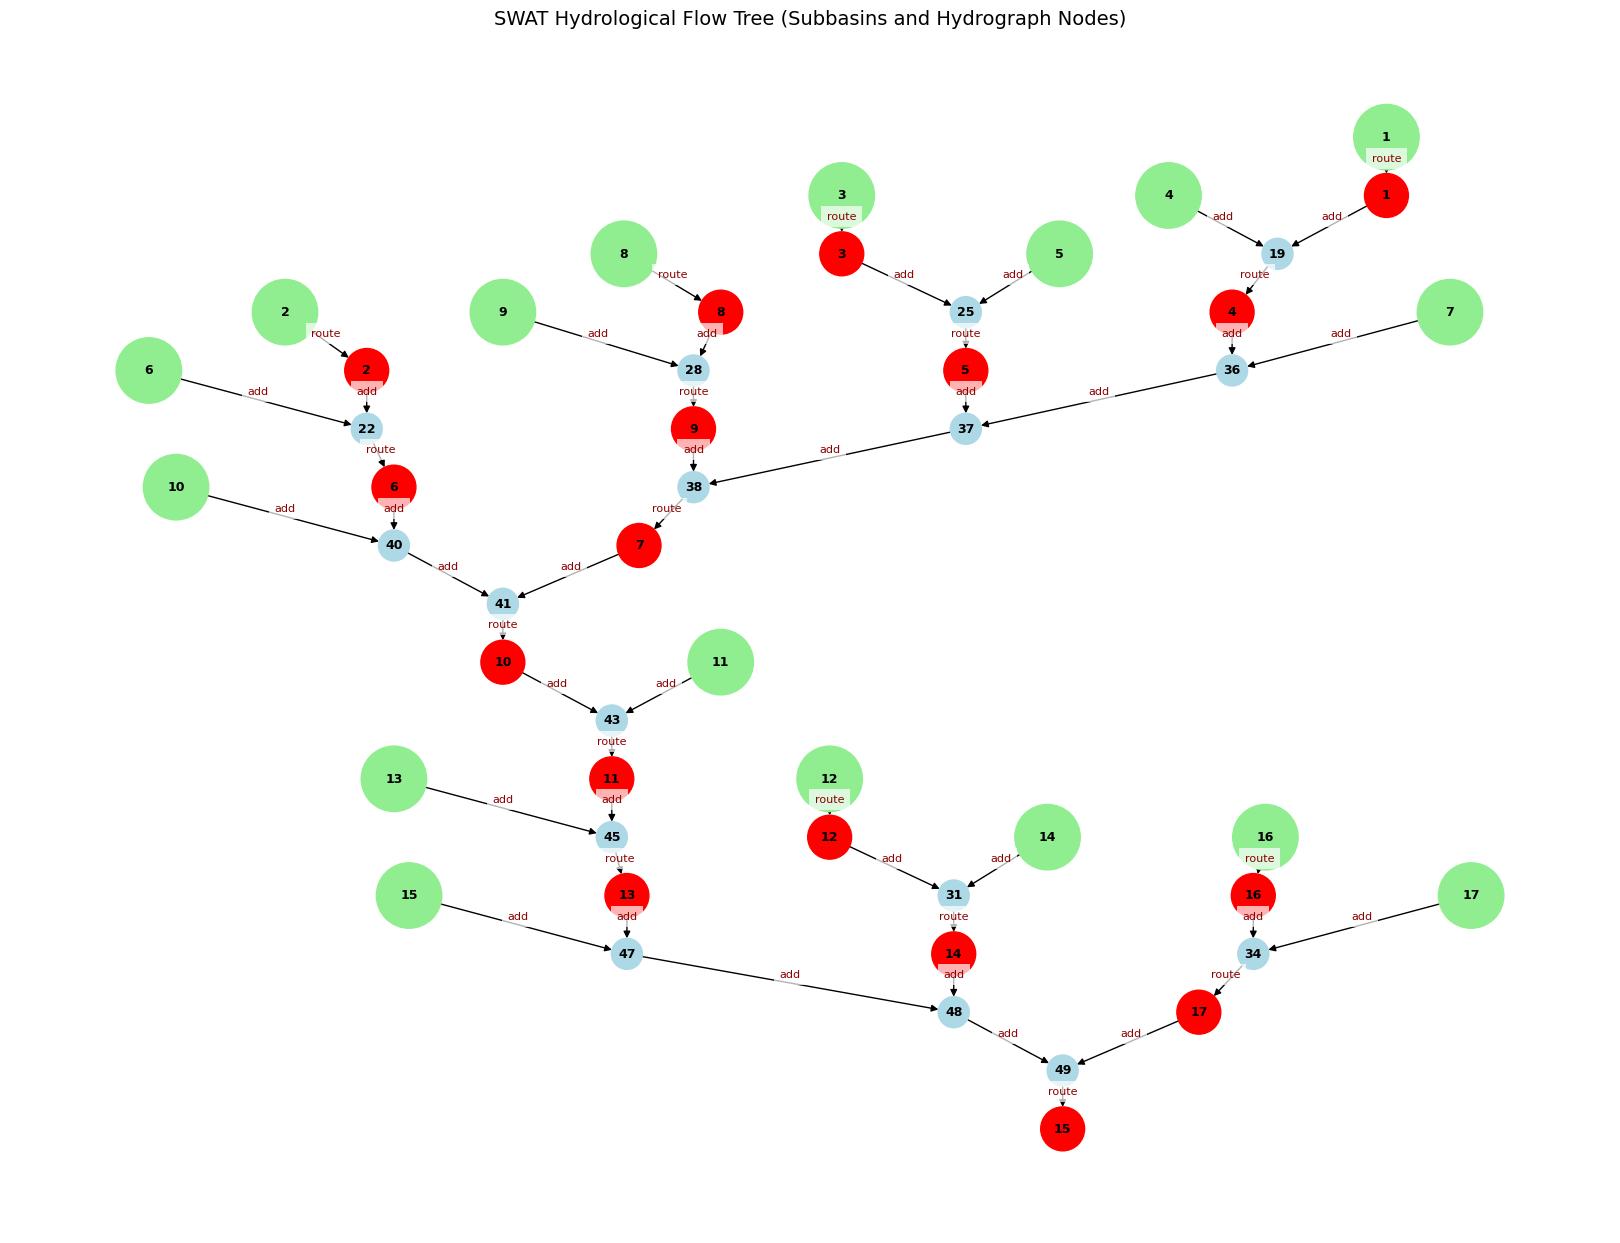

In [4]:
import matplotlib.pyplot as plt
import networkx as nx

fig_path = fig_orig_path  # Path to your .fig file

# --- Parse Commands ---
hyd_stor_to_subbasin = {}
hyd_stor_to_reach = {}

routes = []
adds = []

with open(fig_path, 'r') as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i]
    if len(line) < 34:
        i += 1
        continue

    command = line[10:16].strip()

    if command == "1":  # SUBBASIN
        try:
            hyd_stor = int(line[16:22].strip())
            sub_num = int(line[22:28].strip())
            hyd_stor_to_subbasin[hyd_stor] = sub_num # hyd_stor
        except ValueError:
            pass
        i += 2

    elif command == "2":  # ROUTE
        try:
            inflow_hyd = int(line[28:34].strip())
            hyd_stor = int(line[16:22].strip())
            rch_num = int(line[22:28].strip())
            hyd_stor_to_reach[hyd_stor] =  rch_num # hyd_stor
            routes.append((inflow_hyd, hyd_stor))
        except ValueError:
            pass
        i += 2

    elif command == "5":  # ADD
        try:
            out = int(line[16:22].strip())
            in1 = int(line[22:28].strip())
            in2 = int(line[28:34].strip())
            adds.append((in1, in2, out))
        except ValueError:
            pass
        i += 1
    else:
        i += 1

# --- Build Graph ---
G = nx.DiGraph()

all_nodes = set()
for inflow, outflow in routes:
    all_nodes.add(inflow)
    all_nodes.add(outflow)
for in1, in2, out in adds:
    all_nodes.update([in1, in2, out])
all_nodes.update(hyd_stor_to_subbasin.keys())

for node in all_nodes:
    if node in hyd_stor_to_subbasin:
        label = f"{hyd_stor_to_subbasin[node]}"
        color = 'lightgreen'
        size = 2220
    elif node in hyd_stor_to_reach:
        label = f"{hyd_stor_to_reach[node]}"
        color = 'red'
        size = 1000
    else:
        label = f"{node}"
        color = 'lightblue'
        size = 500
    G.add_node(node, size=size, label=label, color=color)

# Add edges
for inflow, outflow in routes:
    G.add_edge(inflow, outflow, type='route')
for in1, in2, out in adds:
    G.add_edge(in1, out, type='add')
    G.add_edge(in2, out, type='add')

# --- Layout ---
try:
    from networkx.drawing.nx_pydot import graphviz_layout
    pos = graphviz_layout(G, prog='dot')
except ImportError:
    print("Graphviz layout not available, falling back to spring layout.")
    pos = nx.spring_layout(G, seed=42)

# --- Draw Graph ---
plt.figure(figsize=(16, 12))
labels = {n: G.nodes[n]['label'] for n in G.nodes}
edge_labels = {(u, v): G.edges[u, v]['type'] for u, v in G.edges()}

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, labels=labels,
        node_color=[G.nodes[n]['color'] for n in G.nodes], 
        node_size = [G.nodes[n]['size'] for n in G.nodes], 
        font_size=9, 
        font_weight='bold'
    )
        

# Manual placement of edge labels
for (u, v), label in edge_labels.items():
    x = (pos[u][0] + pos[v][0]) / 2
    y = (pos[u][1] + pos[v][1]) / 2
    plt.text(x, y + 10, label, color='darkred', fontsize=8,
             ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

plt.title("SWAT Hydrological Flow Tree (Subbasins and Hydrograph Nodes)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22204\867172545.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


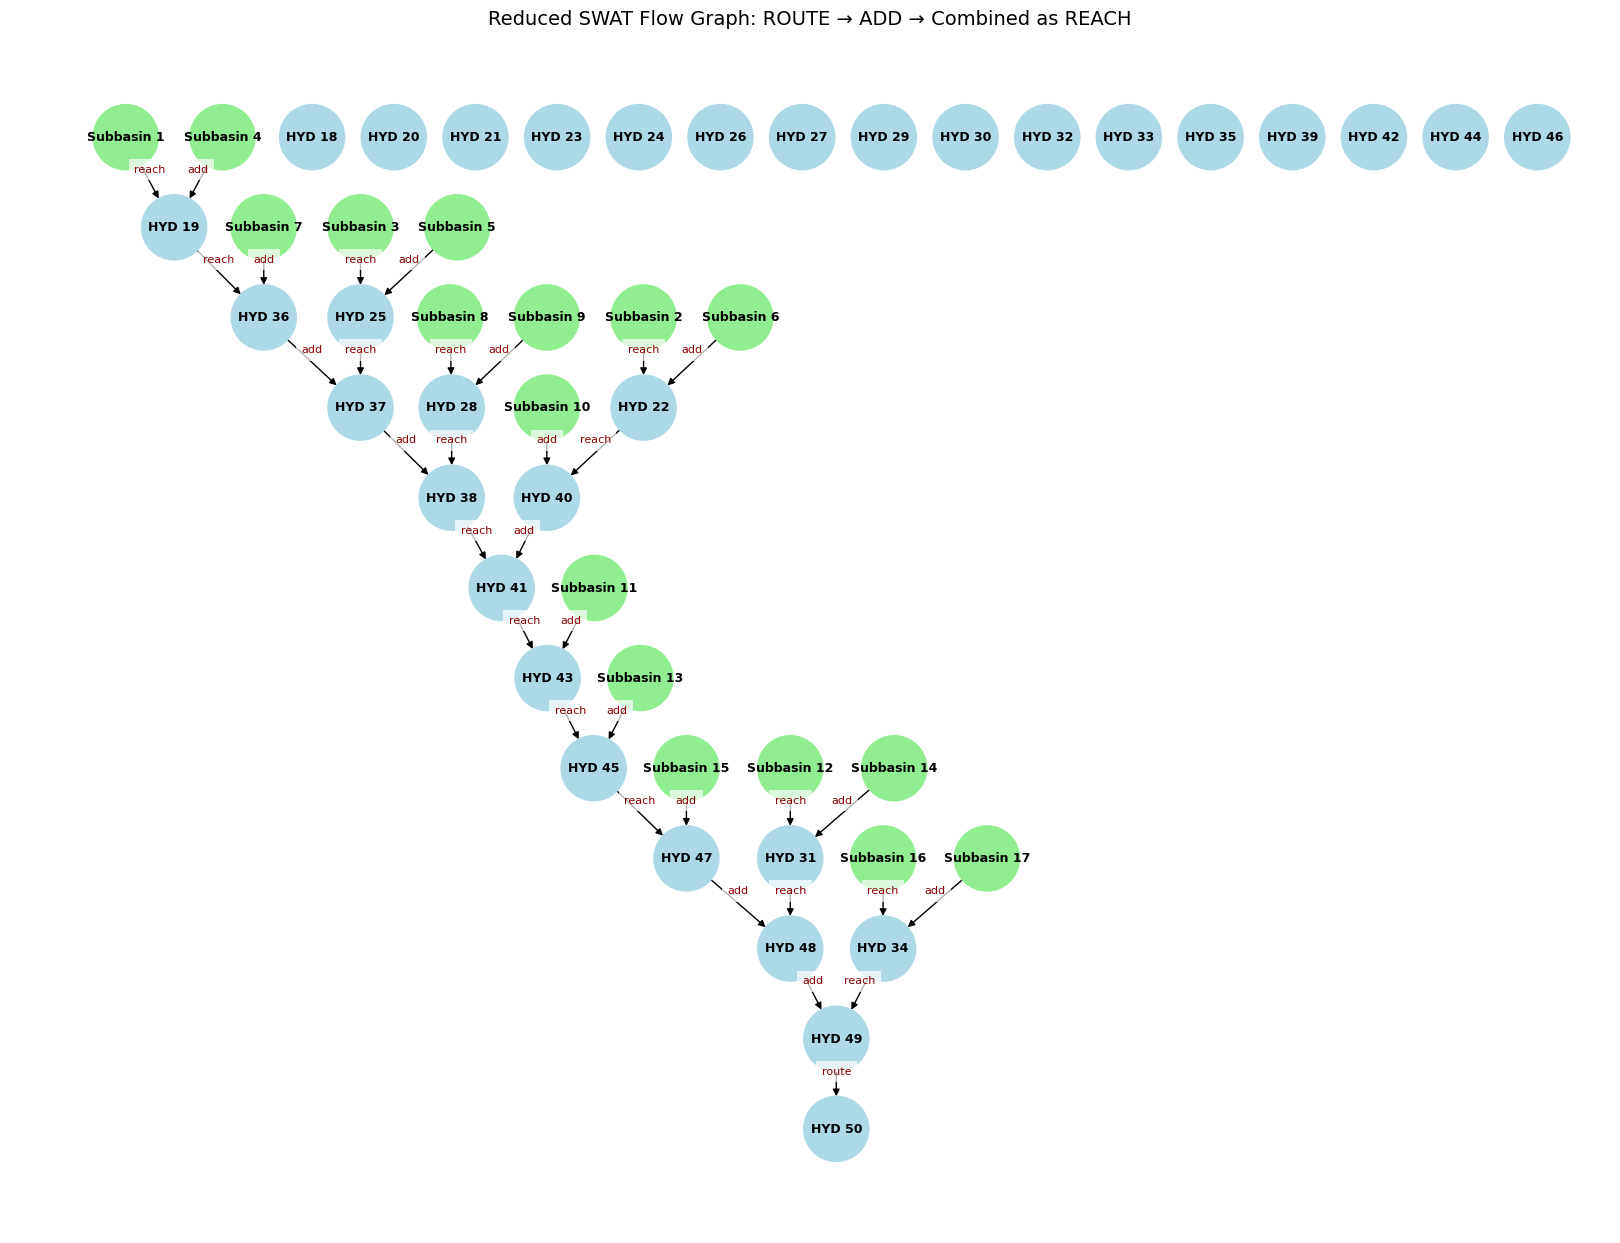

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx

# Use the uploaded .fig file
fig_path = fig_orig_path

# --- Parse Commands ---
hyd_stor_to_subbasin = {}
routes = []
adds = []

with open(fig_path, 'r') as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i]
    if len(line) < 34:
        i += 1
        continue

    command = line[10:16].strip()

    if command == "1":  # SUBBASIN
        try:
            hyd_stor = int(line[16:22].strip())
            sub_num = int(line[22:28].strip())
            hyd_stor_to_subbasin[hyd_stor] = sub_num
        except ValueError:
            pass
        i += 2

    elif command == "2":  # ROUTE
        try:
            hyd_stor = int(line[16:22].strip())
            inflow = int(line[28:34].strip())
            routes.append((inflow, hyd_stor))
        except ValueError:
            pass
        i += 2

    elif command == "5":  # ADD
        try:
            out = int(line[16:22].strip())
            in1 = int(line[22:28].strip())
            in2 = int(line[28:34].strip())
            adds.append((in1, in2, out))
        except ValueError:
            pass
        i += 1
    else:
        i += 1

# --- Build Original Graph ---
G = nx.DiGraph()
all_nodes = set()
for inflow, outflow in routes:
    all_nodes.add(inflow)
    all_nodes.add(outflow)
for in1, in2, out in adds:
    all_nodes.update([in1, in2, out])
all_nodes.update(hyd_stor_to_subbasin.keys())

for node in all_nodes:
    label = f"Subbasin {hyd_stor_to_subbasin[node]}" if node in hyd_stor_to_subbasin else f"HYD {node}"
    color = 'lightgreen' if node in hyd_stor_to_subbasin else 'lightblue'
    G.add_node(node, label=label, color=color)

for inflow, outflow in routes:
    G.add_edge(inflow, outflow, type='route')
for in1, in2, out in adds:
    G.add_edge(in1, out, type='add')
    G.add_edge(in2, out, type='add')

# --- Reduction Function ---
def reduce_route_add_chains(G):
    new_edges = []
    to_remove = set()

    for u, v, d in G.edges(data=True):
        if d.get('type') == 'route':
            # Check if `v` is only used in this route and then in a single add
            successors = list(G.successors(v))
            if len(successors) == 1 and G[v][successors[0]].get('type') == 'add':
                add_target = successors[0]
                new_edges.append((u, add_target))
                to_remove.update([(u, v), (v, add_target)])

    G_reduced = nx.DiGraph()
    for node in G.nodes:
        G_reduced.add_node(node, **G.nodes[node])

    for u, v in G.edges:
        if (u, v) not in to_remove:
            G_reduced.add_edge(u, v, **G.edges[u, v])

    for u, v in new_edges:
        G_reduced.add_edge(u, v, type='reach')

    return G_reduced

# --- Apply Reduction ---
G_reduced = reduce_route_add_chains(G)

# --- Layout and Draw ---
try:
    from networkx.drawing.nx_pydot import graphviz_layout
    pos = graphviz_layout(G_reduced, prog='dot')
except ImportError:
    pos = nx.spring_layout(G_reduced, seed=42)

plt.figure(figsize=(16, 12))
node_colors = [G_reduced.nodes[n]['color'] for n in G_reduced.nodes]
labels = {n: G_reduced.nodes[n]['label'] for n in G_reduced.nodes}
edge_labels = {(u, v): G_reduced.edges[u, v]['type'] for u, v in G_reduced.edges()}

nx.draw(G_reduced, pos, with_labels=True, labels=labels,
        node_color=node_colors, node_size=2200, font_size=9, font_weight='bold')

for (u, v), label in edge_labels.items():
    x = (pos[u][0] + pos[v][0]) / 2
    y = (pos[u][1] + pos[v][1]) / 2
    plt.text(x, y + 10, label, color='darkred', fontsize=8,
             ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

plt.title("Reduced SWAT Flow Graph: ROUTE → ADD → Combined as REACH", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


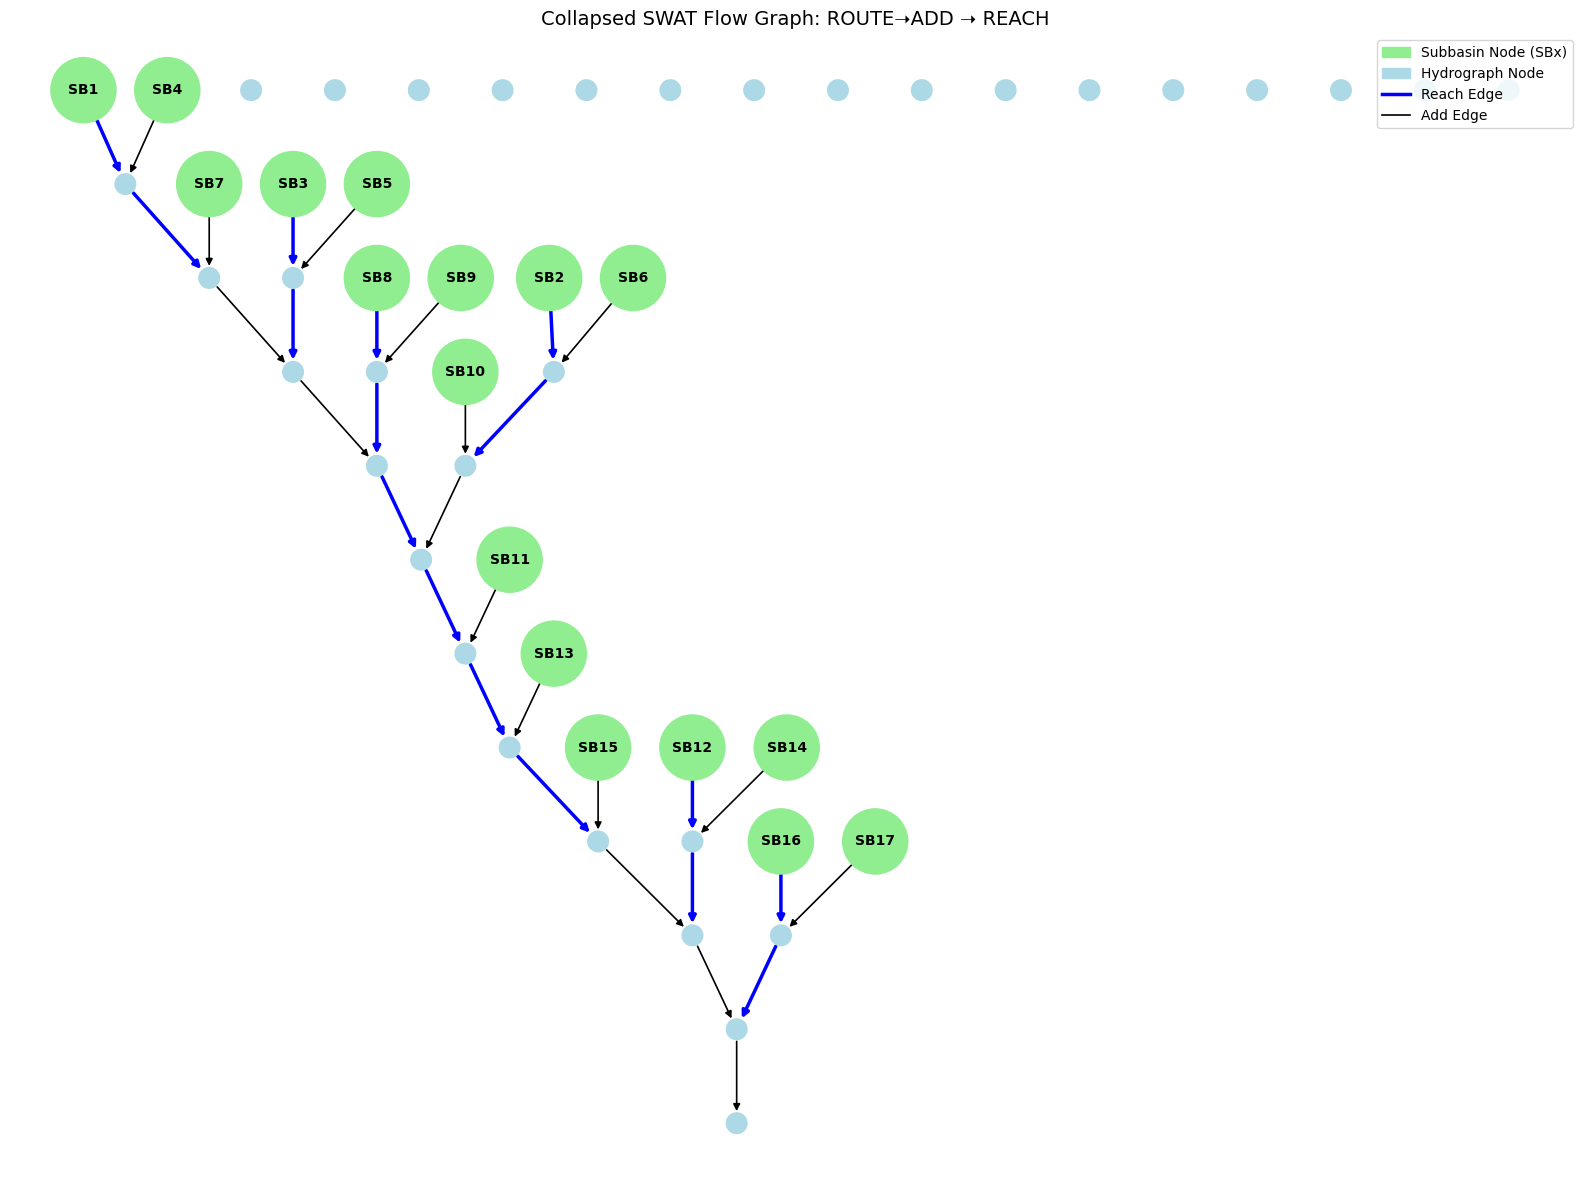

In [6]:
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

fig_path = fig_orig_path  # Update this as needed

# --- Parse Commands ---
hyd_stor_to_subbasin = {}
routes = []
adds = []

with open(fig_path, 'r') as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i]
    if len(line) < 34:
        i += 1
        continue

    command = line[10:16].strip()

    if command == "1":  # SUBBASIN
        try:
            hyd_stor = int(line[16:22].strip())
            sub_num = int(line[22:28].strip())
            hyd_stor_to_subbasin[hyd_stor] = sub_num
        except ValueError:
            pass
        i += 2

    elif command == "2":  # ROUTE
        try:
            hyd_stor = int(line[16:22].strip())
            inflow = int(line[28:34].strip())
            routes.append((inflow, hyd_stor))
        except ValueError:
            pass
        i += 2

    elif command == "5":  # ADD
        try:
            out = int(line[16:22].strip())
            in1 = int(line[22:28].strip())
            in2 = int(line[28:34].strip())
            adds.append((in1, in2, out))
        except ValueError:
            pass
        i += 1
    else:
        i += 1

# --- Build Graph ---
G = nx.DiGraph()
all_nodes = set()
for inflow, outflow in routes:
    all_nodes.update([inflow, outflow])
for in1, in2, out in adds:
    all_nodes.update([in1, in2, out])
all_nodes.update(hyd_stor_to_subbasin.keys())

for node in all_nodes:
    if node in hyd_stor_to_subbasin:
        G.add_node(node,
                   label=f"SB{hyd_stor_to_subbasin[node]}",
                   color='lightgreen',
                   size=2200)
    else:
        G.add_node(node,
                   label="",
                   color='lightblue',
                   size=220)  # 10× smaller

for inflow, outflow in routes:
    G.add_edge(inflow, outflow, type='route')
for in1, in2, out in adds:
    G.add_edge(in1, out, type='add')
    G.add_edge(in2, out, type='add')

# --- Reduction Function ---
def reduce_route_add_chains(G):
    new_edges = []
    to_remove = set()

    for u, v, d in G.edges(data=True):
        if d.get('type') == 'route':
            successors = list(G.successors(v))
            if len(successors) == 1 and G[v][successors[0]].get('type') == 'add':
                add_target = successors[0]
                new_edges.append((u, add_target))
                to_remove.update([(u, v), (v, add_target)])

    G_reduced = nx.DiGraph()
    for node in G.nodes:
        G_reduced.add_node(node, **G.nodes[node])

    for u, v in G.edges:
        if (u, v) not in to_remove:
            G_reduced.add_edge(u, v, **G.edges[u, v])
    for u, v in new_edges:
        G_reduced.add_edge(u, v, type='reach')

    return G_reduced

# --- Apply Reduction ---
G_reduced = reduce_route_add_chains(G)

# --- Layout ---
try:
    from networkx.drawing.nx_pydot import graphviz_layout
    pos = graphviz_layout(G_reduced, prog='dot')
except ImportError:
    pos = nx.spring_layout(G_reduced, seed=42)

# --- Drawing ---
plt.figure(figsize=(16, 12))
node_colors = [G_reduced.nodes[n]['color'] for n in G_reduced.nodes]
node_sizes = [G_reduced.nodes[n]['size'] for n in G_reduced.nodes]
labels = {n: G_reduced.nodes[n]['label'] for n in G_reduced.nodes}

# Draw nodes
nx.draw_networkx_nodes(G_reduced, pos,
                       node_color=node_colors,
                       node_size=node_sizes)

# Draw labels only for subbasins
nx.draw_networkx_labels(G_reduced, pos,
                        labels={n: labels[n] for n in G_reduced.nodes if labels[n]},
                        font_size=10, font_weight='bold')

# Draw edges with style
for u, v in G_reduced.edges():
    edge_type = G_reduced.edges[u, v]['type']
    color = 'blue' if edge_type == 'reach' else 'black'
    width = 2.5 if edge_type == 'reach' else 1.2
    nx.draw_networkx_edges(G_reduced, pos, edgelist=[(u, v)], width=width, edge_color=color)

# --- Add Legend ---
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

legend_elements = [
    mpatches.Patch(color='lightgreen', label='Subbasin Node (SBx)'),
    mpatches.Patch(color='lightblue', label='Hydrograph Node'),
    mlines.Line2D([], [], color='blue', linewidth=2.5, label='Reach Edge'),
    mlines.Line2D([], [], color='black', linewidth=1.2, label='Add Edge')
]

plt.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=10)



plt.title("Collapsed SWAT Flow Graph: ROUTE➝ADD ➝ REACH", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


🔁 Collapsing: Subbasin 1 → HYD 18 → HYD 19
🔁 Collapsing: Subbasin 2 → HYD 21 → HYD 22
🔁 Collapsing: Subbasin 3 → HYD 24 → HYD 25
🔁 Collapsing: Subbasin 8 → HYD 27 → HYD 28
🔁 Collapsing: Subbasin 12 → HYD 30 → HYD 31
🔁 Collapsing: Subbasin 16 → HYD 33 → HYD 34
🔁 Collapsing: HYD 19 → HYD 20 → HYD 36
🔁 Collapsing: HYD 22 → HYD 23 → HYD 40
🔁 Collapsing: HYD 25 → HYD 26 → HYD 37
🔁 Collapsing: HYD 28 → HYD 29 → HYD 38
🔁 Collapsing: HYD 31 → HYD 32 → HYD 48
🔁 Collapsing: HYD 34 → HYD 35 → HYD 49
🔁 Collapsing: HYD 38 → HYD 39 → HYD 41
🔁 Collapsing: HYD 41 → HYD 42 → HYD 43
🔁 Collapsing: HYD 43 → HYD 44 → HYD 45
🔁 Collapsing: HYD 45 → HYD 46 → HYD 47


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22204\3276014627.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


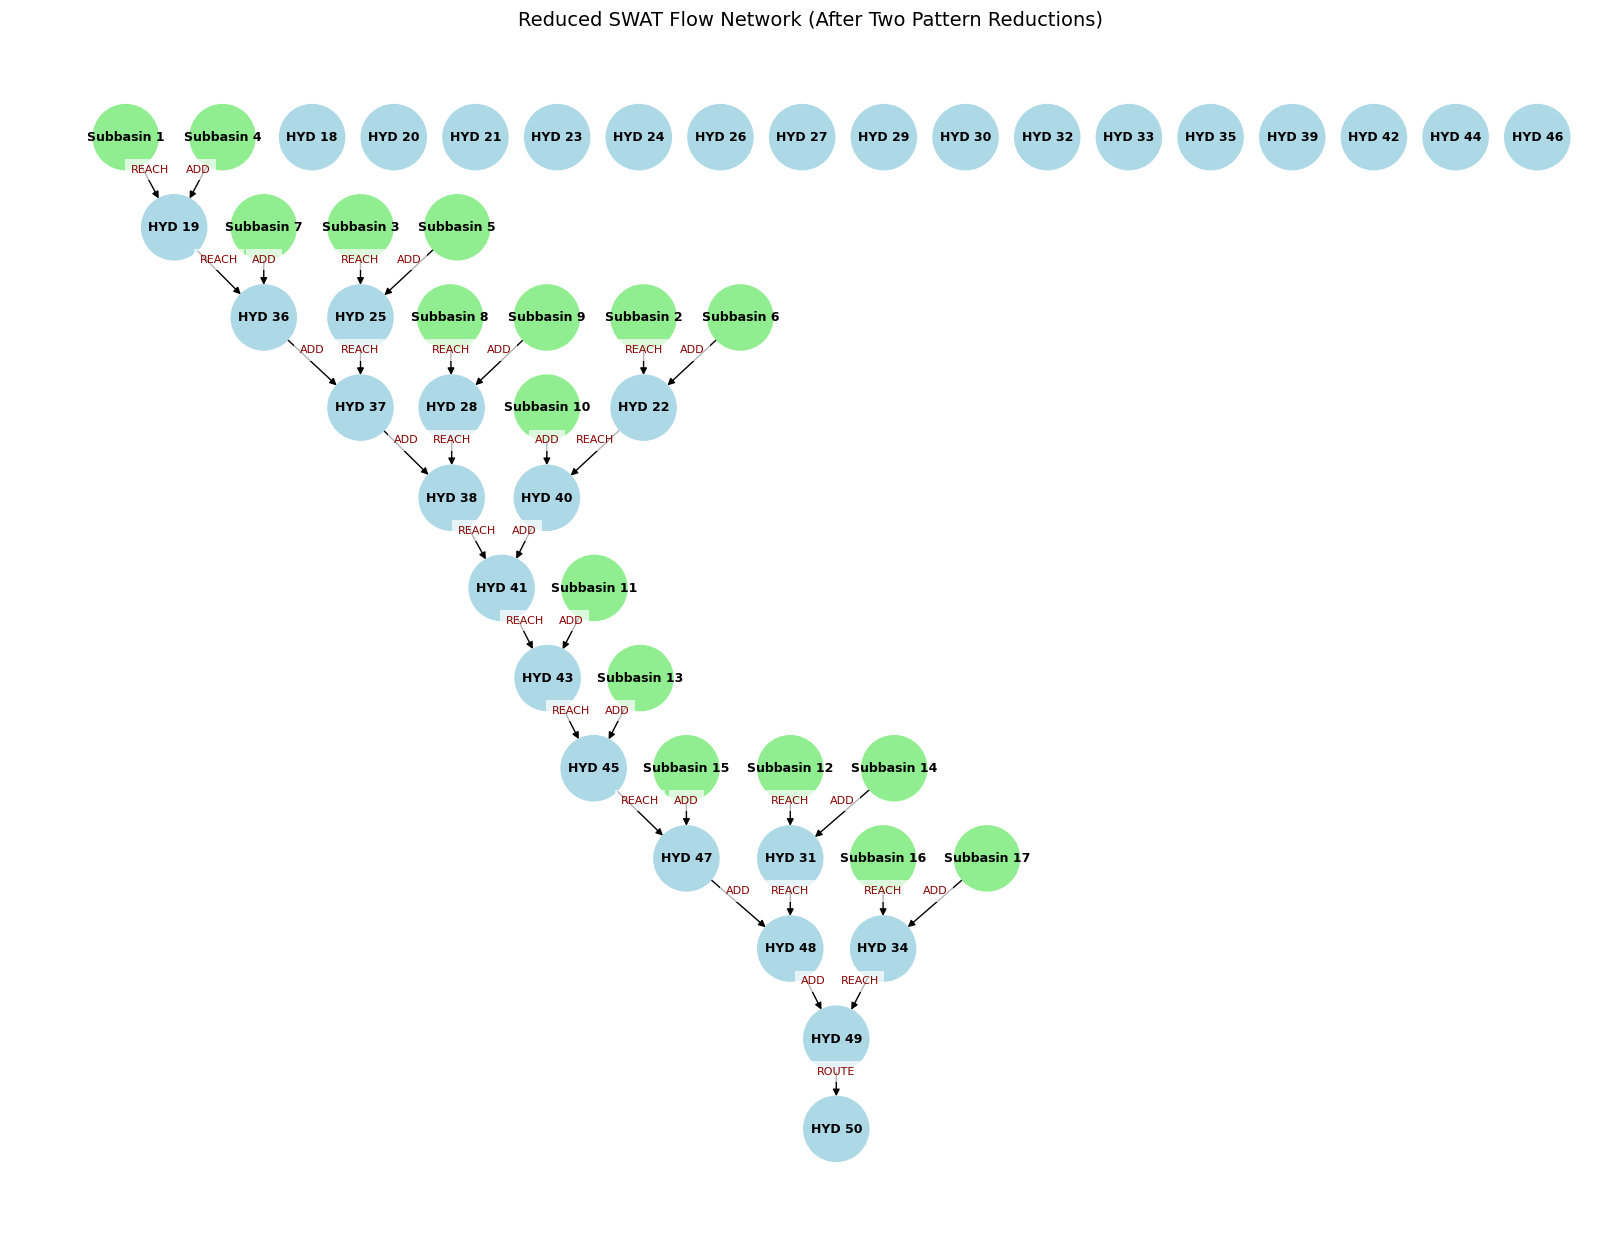

In [7]:
import matplotlib.pyplot as plt
import networkx as nx

fig_path = fig_orig_path  # your original .fig path

# --- Step 1: Parse Commands ---
hyd_stor_to_subbasin = {}
routes = []
adds = []

with open(fig_path, 'r') as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i]
    if len(line) < 34:
        i += 1
        continue

    command = line[10:16].strip()

    if command == "1":
        try:
            hyd_stor = int(line[16:22].strip())
            sub_num = int(line[22:28].strip())
            hyd_stor_to_subbasin[hyd_stor] = sub_num
        except ValueError:
            pass
        i += 2

    elif command == "2":
        try:
            hyd_stor = int(line[16:22].strip())
            inflow = int(line[28:34].strip())
            routes.append((inflow, hyd_stor))
        except ValueError:
            pass
        i += 2

    elif command == "5":
        try:
            out = int(line[16:22].strip())
            in1 = int(line[22:28].strip())
            in2 = int(line[28:34].strip())
            adds.append((in1, in2, out))
        except ValueError:
            pass
        i += 1
    else:
        i += 1

# --- Step 2: Build Graph ---
G = nx.DiGraph()
all_nodes = set()
for inflow, outflow in routes:
    all_nodes.add(inflow)
    all_nodes.add(outflow)
for in1, in2, out in adds:
    all_nodes.update([in1, in2, out])
all_nodes.update(hyd_stor_to_subbasin.keys())

for node in all_nodes:
    label = f"Subbasin {hyd_stor_to_subbasin[node]}" if node in hyd_stor_to_subbasin else f"HYD {node}"
    color = 'lightgreen' if node in hyd_stor_to_subbasin else 'lightblue'
    G.add_node(node, label=label, color=color)

for inflow, outflow in routes:
    G.add_edge(inflow, outflow, type='ROUTE')
for in1, in2, out in adds:
    G.add_edge(in1, out, type='ADD')
    G.add_edge(in2, out, type='ADD')

# --- Step 3: First Reduction Function ---
def reduce_route_add_pattern(G):
    G_reduced = G.copy()
    new_edges = []
    remove_edges = []

    for u, mid, attr1 in G.edges(data=True):
        if attr1.get("type") == "ROUTE":
            for mid2, v, attr2 in G.out_edges(mid, data=True):
                if mid == mid2 and attr2.get("type") == "ADD":
                    print(f"🔁 Collapsing: {G.nodes[u]['label']} → {G.nodes[mid]['label']} → {G.nodes[v]['label']}")
                    new_edges.append((u, v))
                    remove_edges.append((u, mid))
                    remove_edges.append((mid, v))

    for u, v in remove_edges:
        if G_reduced.has_edge(u, v):
            G_reduced.remove_edge(u, v)
    for u, v in new_edges:
        G_reduced.add_edge(u, v, type="REACH")

    return G_reduced

# --- Step 4: Apply two rounds of reduction
G_reduced = reduce_route_add_pattern(G)
G_reduced_final = reduce_route_add_pattern(G_reduced)

# --- Step 5: Visualization ---
try:
    from networkx.drawing.nx_pydot import graphviz_layout
    pos = graphviz_layout(G_reduced_final, prog='dot')
except ImportError:
    print("Graphviz layout not available, falling back to spring layout.")
    pos = nx.spring_layout(G_reduced_final, seed=42)

plt.figure(figsize=(16, 12))
node_colors = [G_reduced_final.nodes[n]['color'] for n in G_reduced_final.nodes]
labels = {n: G_reduced_final.nodes[n]['label'] for n in G_reduced_final.nodes}
edge_labels = {(u, v): G_reduced_final.edges[u, v]['type'] for u, v in G_reduced_final.edges()}

nx.draw(G_reduced_final, pos, with_labels=True, labels=labels,
        node_color=node_colors, node_size=2200, font_size=9, font_weight='bold')
for (u, v), label in edge_labels.items():
    x = (pos[u][0] + pos[v][0]) / 2
    y = (pos[u][1] + pos[v][1]) / 2
    plt.text(x, y + 10, label, color='darkred', fontsize=8,
             ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

plt.title("Reduced SWAT Flow Network (After Two Pattern Reductions)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


# Change .fig file 

Given the original fig.fig file and a folder with one .dat file per point source / subbasin this constructs the correct fig.fig with the point sources included.

the naming convention of this code for .dat files is rcyr_X.dat where X is the number corresponding to the subbasin the point source is associated with.

SWAT allows only 13 character .dat file names (incl. the extension)

In [ ]:
import os
import re

# Define paths
fig_input_path = "./original .fig/fig.fig"
fig_output_path = "./modified .fig/fig.fig"
dat_directory = "../../swat_ready_recyear_files" # Update this to the actual path where your recyear_XX.dat files are located

# Load original fig.fig file
with open(fig_input_path, "r") as file:
    fig_lines = file.readlines()

# Extract all subbasin commands
subbasins = []
i = 0
while i < len(fig_lines):
    line = fig_lines[i]
    if line.strip().startswith("*"):
        i += 1
        continue
    if line[10:16].strip() == "1":  # SUBBASIN
        try:
            cmd = {
                "COMMAND": int(line[10:16]),
                "HYD_STOR": int(line[16:22]),
                "SUB_NUM": int(line[22:28]),
                "GIS_CODE": line[46:55].strip() if len(line) >= 55 else None,
                "SUBFILE": fig_lines[i+1][10:23].strip(),
                "line_idx": i
            }
            subbasins.append(cmd)
        except ValueError:
            pass
        i += 2
    else:
        i += 1
        # Get all recyear_XX.dat files
        available_subs = set()
        area_by_sub = {}


        # Read all .dat files in the specified directory and extract drainage area and format it according to F90 6.3f format BUT not extactly 6.3f, but 6.2f if area >= 100 (othersise 106.123 would need to become 06.123)
        for filename in os.listdir(dat_directory):
            match = re.search(r"rcyr_(\d+)\.dat", filename)
            if match:
                sub_num = int(match.group(1))
                available_subs.add(sub_num)
                # Read drainage area from first line of .dat file
                dat_path = os.path.join(dat_directory, filename)
                with open(dat_path, "r") as dat_file:
                    first_line = dat_file.readline()
                    area_match = re.search(r"DRAINAGE_AREA in km2:\s*([0-9.]+)", first_line)
                    if area_match:
                        area_val = float(area_match.group(1))
                        # If area >= 100, round to 2 decimals to fit width 6, else keep 3 decimals
                        if area_val >= 100:
                            area_str = f"{area_val:6.2f}"
                        else:
                            area_str = f"{area_val:6.3f}"
                        area_by_sub[sub_num] = area_str[-6:]
                    else:
                        area_by_sub[sub_num] = f"{0.0:6.3f}"

        # Filter subbasins with corresponding recyear data
        target_subs = [sb for sb in subbasins if sb["SUB_NUM"] in available_subs]

        # Construct RECYEAR lines
        recyear_lines = []
        for idx, sb in enumerate(target_subs):
            prefix = "recyear".ljust(10)
            file_number = sb["SUB_NUM"]
            filename = f"rcyr_{file_number}.dat"
            hyd_stor = 900 + idx + 1
            area = area_by_sub.get(file_number, f"{0.0:6.3f}")[-6:]
            # Place area at position 41-46 (right-aligned in 6 chars)
            line1 = f"{prefix}{8:6d}{hyd_stor:6d}{file_number:6d}{'':12}\n" #{area}\n"
            line2 = f"{'pnt.source':10}{filename.rjust(13):13}\n"
            recyear_lines.append(line1)
            recyear_lines.append(line2)

# Find index right after last SUBBASIN command
last_sub_idx = max([sb["line_idx"] for sb in subbasins]) + 2

# Insert RECYEAR blocks
modified_fig_lines = fig_lines[:last_sub_idx] + recyear_lines + fig_lines[last_sub_idx:]

# Ensure output directory exists
os.makedirs(os.path.dirname(fig_output_path), exist_ok=True)

# Save modified fig.fig
with open(fig_output_path, "w") as file:
    file.writelines(modified_fig_lines)

fig_output_path


'./modified .fig/fig.fig'

In [33]:
import os
import re

# Define paths
fig_output_path = "./modified .fig/fig.fig"
fig_input_path = fig_output_path  # reuse previous output
dat_directory = "../swat_ready_recyear_files"

# --- Load FIG file ---
with open(fig_input_path, "r") as file:
    fig_lines = file.readlines()

# --- Parse subbasins ---
subbasins = {}
i = 0
while i < len(fig_lines):
    line = fig_lines[i]
    if line.strip().startswith("*"):
        i += 1
        continue
    if line[10:16].strip() == "1":  # SUBBASIN
        try:
            sub_num = int(line[22:28])
            hyd_stor = int(line[16:22])
            subbasins[sub_num] = {
                "HYD_STOR": hyd_stor,
                "line_idx": i
            }
        except ValueError:
            pass
        i += 2
    else:
        i += 1

# --- Apply ADD and ROUTE logic ---
new_lines = []
i = 0
while i < len(fig_lines):
    line = fig_lines[i]

    # --- ADD command modification ---
    if line[10:16].strip() == "5":
        try:
            add_hyd_stor = int(line[16:22])
            hyd_num1 = int(line[22:28])
            hyd_num2 = int(line[28:34])

            if hyd_num1 in subbasins:
                print(f"Injecting ADD for ADD command with HYD_NUM1 = {hyd_num1} at line {i}")
                sub_num = hyd_num1
                orig_sub_hyd_stor = subbasins[sub_num]["HYD_STOR"]
                recyear_hyd_stor = 900 + sub_num
                new_add_hyd_stor = 1000 + sub_num * 2

                prefix = "add".ljust(10)

                new_add_line = f"{prefix}{5:6d}{new_add_hyd_stor:6d}{orig_sub_hyd_stor:6d}{recyear_hyd_stor:6d}\n"
                new_lines.append(new_add_line)

                modified_line = f"{prefix}{5:6d}{add_hyd_stor:6d}{new_add_hyd_stor:6d}{hyd_num2:6d}\n"
                new_lines.append(modified_line)
                i += 1
                continue
        except ValueError:
            pass

    # --- ROUTE command modification ---
    elif line[10:16].strip() == "2" and (i + 1 < len(fig_lines)):
        try:
            hyd_stor = int(line[16:22])
            rch_num = int(line[22:28])
            hyd_num = int(line[28:34])
            rtefile = fig_lines[i+1][10:23]
            swqfile = fig_lines[i+1][23:36]

            if hyd_num in subbasins:
                print(f"Injecting ADD for ROUTE with HYD_NUM = {hyd_num} at line {i}")
                sub_num = hyd_num
                orig_sub_hyd_stor = subbasins[sub_num]["HYD_STOR"]
                recyear_hyd_stor = 900 + sub_num
                new_add_hyd_stor = 2000 + sub_num * 2

                # Insert new ADD
                prefix = "add".ljust(10)
                new_add_line = f"{prefix}{5:6d}{new_add_hyd_stor:6d}{orig_sub_hyd_stor:6d}{recyear_hyd_stor:6d}\n"
                new_lines.append(new_add_line)

                # Modify ROUTE line
                prefix = "route".ljust(10)
                route_line = (
                    f"{prefix}{2:6d}{hyd_stor:6d}{rch_num:6d}{new_add_hyd_stor:6d}"
#######################################################################
#                    f"{'':6s}{'':6s}{'':6s}{0.0:6.1f}\n"  ############# the documentation says that the FLOW_OVN variable is required, but the original .fig file does not have it ---- here we set it to 0.0; but need to check if this is correct
#######################################################################
                    f"\n"           
                )
                route_meta = f"{'':10}{rtefile:<13}{swqfile:<13}\n"

                new_lines.append(route_line)
                new_lines.append(route_meta)
                i += 2
                continue
        except ValueError:
            pass

    # If nothing matched, just copy line
    new_lines.append(line)
    i += 1

# --- Save updated .fig file ---
os.makedirs(os.path.dirname(fig_output_path), exist_ok=True)
with open(fig_output_path, "w") as file:
    file.writelines(new_lines)


Injecting ADD for ROUTE with HYD_NUM = 1 at line 68
Injecting ADD for ADD command with HYD_NUM1 = 4 at line 70
Injecting ADD for ROUTE with HYD_NUM = 2 at line 73
Injecting ADD for ADD command with HYD_NUM1 = 6 at line 75
Injecting ADD for ROUTE with HYD_NUM = 3 at line 78
Injecting ADD for ADD command with HYD_NUM1 = 5 at line 80
Injecting ADD for ROUTE with HYD_NUM = 8 at line 83
Injecting ADD for ADD command with HYD_NUM1 = 9 at line 85
Injecting ADD for ROUTE with HYD_NUM = 12 at line 88
Injecting ADD for ADD command with HYD_NUM1 = 14 at line 90
Injecting ADD for ROUTE with HYD_NUM = 16 at line 93
Injecting ADD for ADD command with HYD_NUM1 = 17 at line 95
Injecting ADD for ADD command with HYD_NUM1 = 7 at line 98
Injecting ADD for ADD command with HYD_NUM1 = 10 at line 103
Injecting ADD for ADD command with HYD_NUM1 = 11 at line 107
Injecting ADD for ADD command with HYD_NUM1 = 13 at line 110
Injecting ADD for ADD command with HYD_NUM1 = 15 at line 113


## Visualizing changed .fig


1p.dat


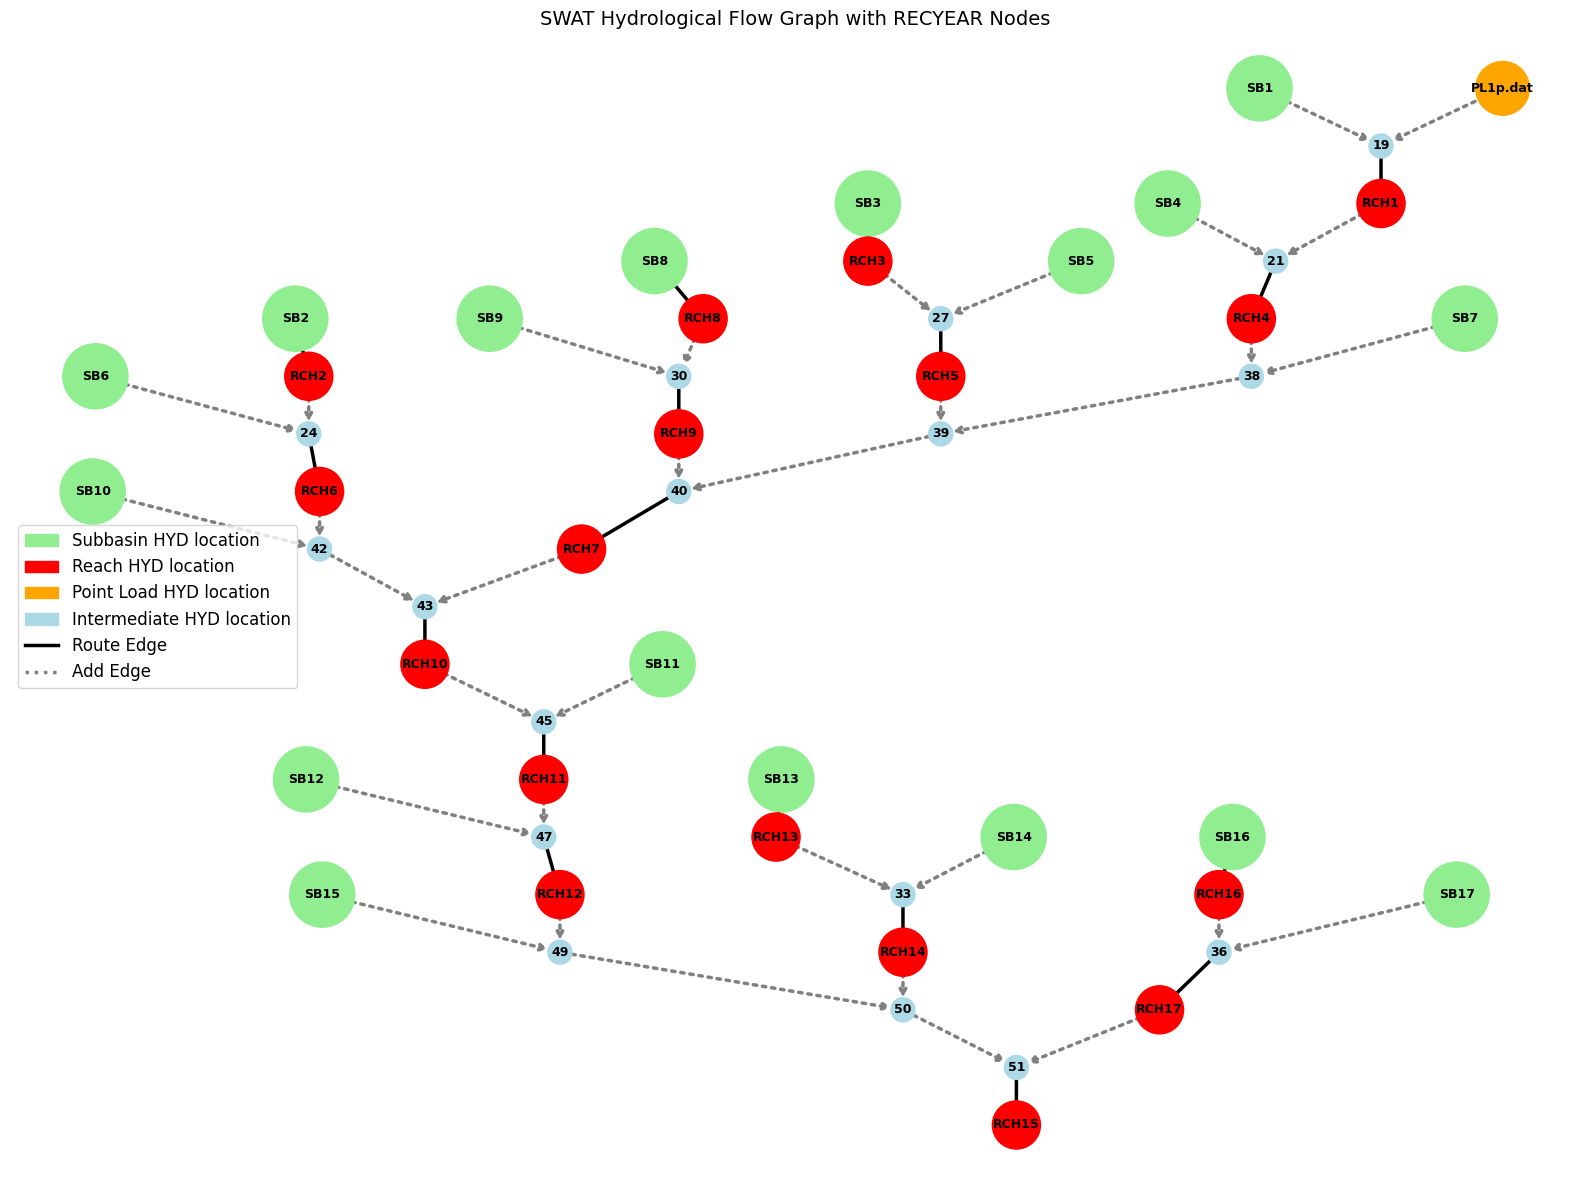

In [5]:
import os
import matplotlib.pyplot as plt
import networkx as nx

fig_path = fig_modi_path  # Adjust path to .fig file

# --- Containers ---
subbasins, routes, adds, recyears = [], [], [], []
hyd_stor_to_subbasin = {}
hyd_stor_to_reach = {}
hyd_stor_to_recyear = {}

# --- Parse Commands ---
with open(fig_path, 'r') as f:
    fig_lines = f.readlines()

i = 0
while i < len(fig_lines):
    line = fig_lines[i]
    if line.strip().startswith("*"):
        i += 1
        continue

    command = line[10:16].strip()

    if command == "1":  # SUBBASIN
        try:
            cmd = {
                "COMMAND": int(line[10:16]),
                "HYD_STOR": int(line[16:22]),
                "SUB_NUM": int(line[22:28]),
                "GIS_CODE": line[46:55].strip() if len(line) >= 55 else None,
                "SUBFILE": fig_lines[i+1][10:23].strip()
            }
            hyd_stor_to_subbasin[cmd["HYD_STOR"]] = cmd["SUB_NUM"]
            subbasins.append(cmd)
        except ValueError:
            pass
        i += 2

    elif command == "2":  # ROUTE
        try:
            cmd = {
                "COMMAND": int(line[10:16]),
                "HYD_STOR": int(line[16:22]),
                "RCH_NUM": int(line[22:28]),
                "HYD_NUM": int(line[28:34]),
                "FLOW_OVN": float(line[40:46].strip() or 0.0),
                "RTEFILE": fig_lines[i+1][10:23].strip(),
                "SWQFILE": fig_lines[i+1][23:36].strip()
            }
            hyd_stor_to_reach[cmd["HYD_STOR"]] = cmd["RCH_NUM"] # cmd["HYD_STOR"] #cmd["RCH_NUM"]
            routes.append(cmd)
        except ValueError:
            pass
        i += 2

    elif command == "5":  # ADD
        cmd = {
            "COMMAND": int(line[10:16]),
            "HYD_STOR": int(line[16:22]),
            "HYD_NUM1": int(line[22:28]),
            "HYD_NUM2": int(line[28:34])
        }
        adds.append(cmd)
        i += 1

    elif command == "8":  # RECYEAR
        try:
            cmd = {
                "COMMAND": int(line[10:16]),
                "HYD_STOR": int(line[16:22]),
                "FILEYR_NUM": int(line[22:28]),
                #"DRAINAGE_AREA": float(line[40:46]),
                "FILE_YR": fig_lines[i+1][10:23].strip()
            }
            print(cmd["FILE_YR"])
            hyd_stor_to_recyear[cmd["HYD_STOR"]] =  cmd["FILE_YR"] # cmd["HYD_STOR"] #cmd["FILE_YR"]
            recyears.append(cmd)
        except ValueError:
            print(f"Error parsing RECYEAR command at line {i}: {line.strip()}")
            pass
        i += 2

    else:
        i += 1

# --- Build Graph ---
G = nx.DiGraph()
all_nodes = set()

# Collect all unique hydrologic storages
for cmd in routes:
    all_nodes.update([cmd["HYD_NUM"], cmd["HYD_STOR"]])
for cmd in adds:
    all_nodes.update([cmd["HYD_NUM1"], cmd["HYD_NUM2"], cmd["HYD_STOR"]])
all_nodes.update(hyd_stor_to_subbasin.keys())
all_nodes.update(hyd_stor_to_recyear.keys())

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Add nodes with styles
for node in all_nodes:
    if node in hyd_stor_to_subbasin:
        label = f"SB{hyd_stor_to_subbasin[node]}"
        color = 'lightgreen'
        size = 2200
    elif node in hyd_stor_to_reach:
        label = f"RCH{hyd_stor_to_reach[node]}"
        color = 'red'
        size = 1200
    elif node in hyd_stor_to_recyear:
        label = f"PL{hyd_stor_to_recyear[node]}"
        color = 'orange'
        size = 1500
    else:
        label = node  # unlabeled hydrograph nodes
        color = 'lightblue'
        size = 300
    G.add_node(node, label=label, color=color, size=size)

# Add edges
for cmd in routes:
    G.add_edge(cmd["HYD_NUM"], cmd["HYD_STOR"], type="route")
for cmd in adds:
    G.add_edge(cmd["HYD_NUM1"], cmd["HYD_STOR"], type="add")
    G.add_edge(cmd["HYD_NUM2"], cmd["HYD_STOR"], type="add")
for cmd in recyears:
    # Connect recyear node to the storage it belongs to
    G.add_edge(cmd["HYD_STOR"], cmd["HYD_STOR"], type="recyear")  # Self-loop for visual distinction

# --- Layout ---
try:
    from networkx.drawing.nx_pydot import graphviz_layout
    pos = graphviz_layout(G, prog='dot')
except ImportError:
    pos = nx.spring_layout(G, seed=42)

# --- Draw Graph ---
plt.figure(figsize=(16, 12))
node_colors = [G.nodes[n]['color'] for n in G.nodes]
node_sizes = [G.nodes[n]['size'] for n in G.nodes]
labels = {n: G.nodes[n]['label'] for n in G.nodes}
edge_labels = {(u, v): G.edges[u, v]['type'] for u, v in G.edges()}

# Draw nodes and labels
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_labels(G, pos,
    labels={n: labels[n] for n in G.nodes if labels[n]},
    font_size=9, font_weight='bold')

# Edge styling
for (u, v) in G.edges():
    t = G.edges[u, v]['type']
    if t == 'route':
        color = 'black'
        style = 'solid'
        width = 2.5
    elif t == 'add':
        color = 'gray'
        style = 'dotted'
        width = 2.5
    else:
        color = 'orange'
        style = 'dashed'
        width = 1.5
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], edge_color=color, width=width, style=style)

# --- Legend ---
legend_elements = [
    mpatches.Patch(color='lightgreen', label='Subbasin HYD location'),
    mpatches.Patch(color='red', label='Reach HYD location'),
    mpatches.Patch(color='orange', label='Point Load HYD location'),
    mpatches.Patch(color='lightblue', label='Intermediate HYD location'),
    mlines.Line2D([], [], color='black', linestyle='solid', linewidth=2.5, label='Route Edge'),
    mlines.Line2D([], [], color='gray', linestyle='dotted', linewidth=2.5, label='Add Edge'),
]
plt.legend(handles=legend_elements, loc='center left', fontsize=12, frameon=True)

plt.title("SWAT Hydrological Flow Graph with RECYEAR Nodes", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


# Archive

C:\Users\PW\AppData\Local\Temp\ipykernel_17768\2549575364.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


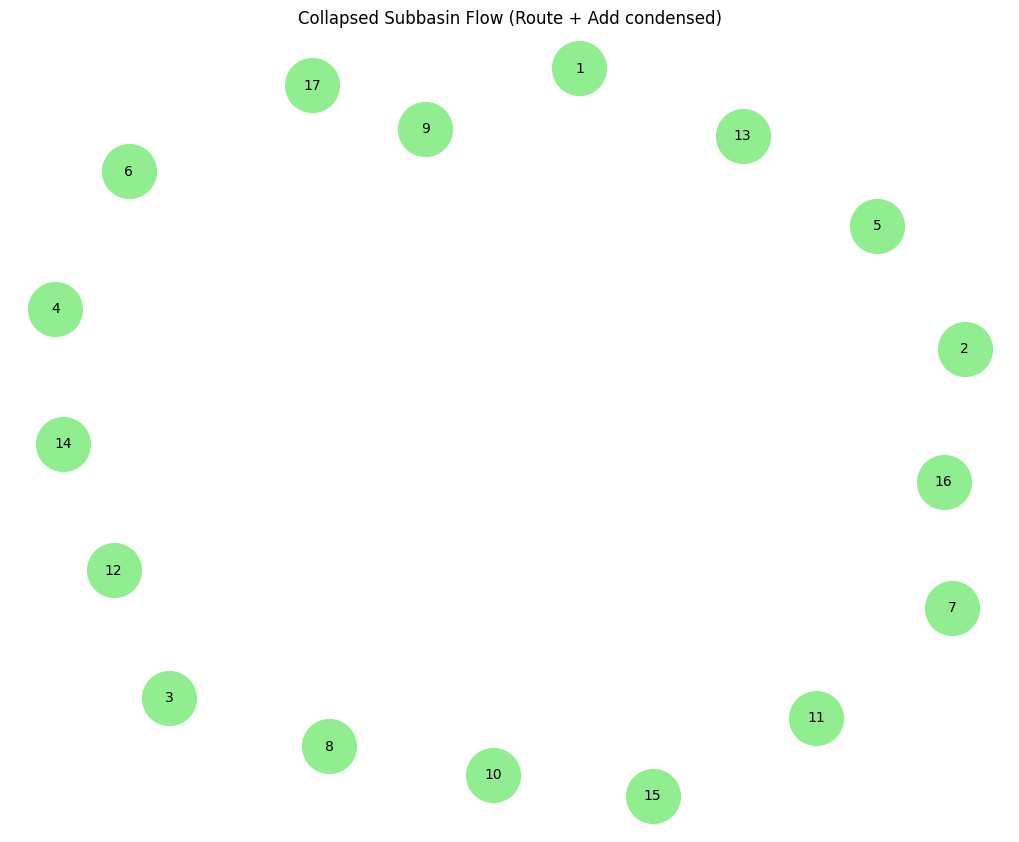

In [ ]:
condensed_edges = collapse_routes_and_adds(hyd_stor_to_subbasin, routes, adds)

G = nx.DiGraph()
subbasins = set(hyd_stor_to_subbasin.values())
G.add_nodes_from(subbasins)

for src, dst in condensed_edges:
    G.add_edge(src, dst)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=1500, font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): "reach" for u, v in G.edges()}, font_color='blue')
plt.title("Collapsed Subbasin Flow (Route + Add condensed)")
plt.axis("off")
plt.tight_layout()
plt.show()


C:\Users\PW\AppData\Local\Temp\ipykernel_2448\1832916997.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


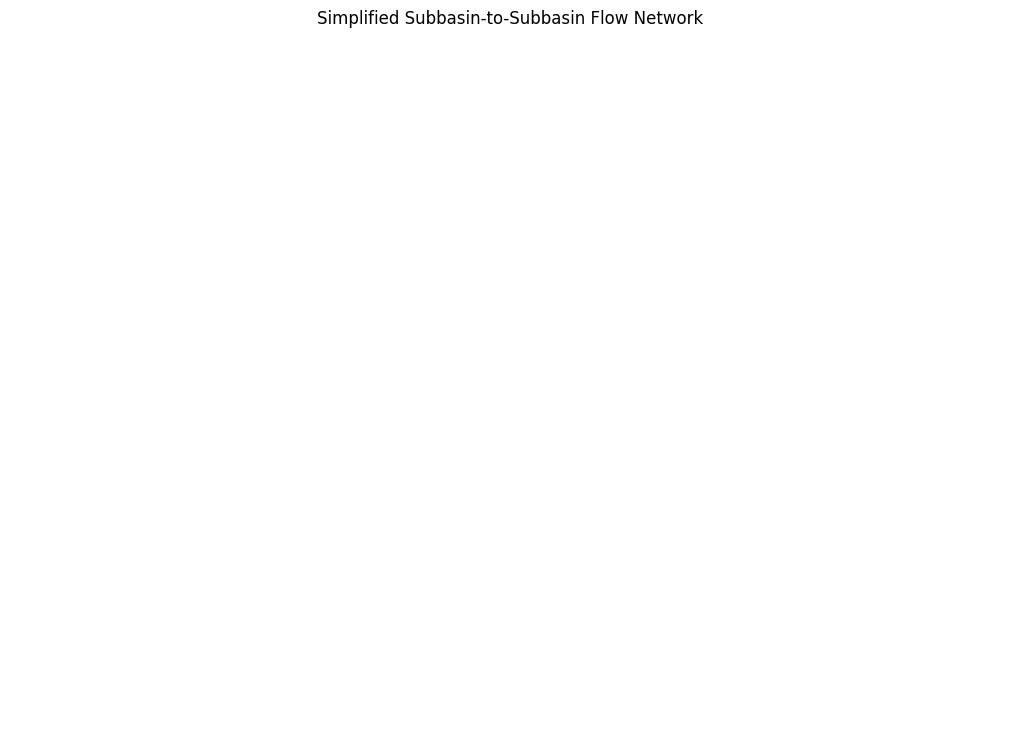

In [ ]:
# Use previously parsed structures (hyd_stor_to_subbasin, routes)
# Filter routes where both inflow and outflow can be mapped to subbasins
subbasin_edges = []
for inflow, outflow in routes:
    if inflow in hyd_stor_to_subbasin and outflow in hyd_stor_to_subbasin:
        upstream_sub = hyd_stor_to_subbasin[inflow]
        downstream_sub = hyd_stor_to_subbasin[outflow]
        subbasin_edges.append((upstream_sub, downstream_sub))

# Create graph
SG = nx.DiGraph()
SG.add_edges_from(subbasin_edges)

# Draw
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(SG, seed=42)
nx.draw(SG, pos, with_labels=True, node_color='lightgreen', node_size=1500, arrows=True, font_weight='bold')
nx.draw_networkx_edge_labels(SG, pos, edge_labels={(u, v): f"{u}→{v}" for u, v in SG.edges()}, font_color='gray')
plt.title("Simplified Subbasin-to-Subbasin Flow Network")
plt.tight_layout()
plt.show()

## direct subbasin filtered graph construction

🟢 Subbasin 1 uses HYD_STOR 1
🟢 Subbasin 2 uses HYD_STOR 2
🟢 Subbasin 3 uses HYD_STOR 3
🟢 Subbasin 4 uses HYD_STOR 4
🟢 Subbasin 5 uses HYD_STOR 5
🟢 Subbasin 6 uses HYD_STOR 6
🟢 Subbasin 7 uses HYD_STOR 7
🟢 Subbasin 8 uses HYD_STOR 8
🟢 Subbasin 9 uses HYD_STOR 9
🟢 Subbasin 10 uses HYD_STOR 10
🟢 Subbasin 11 uses HYD_STOR 11
🟢 Subbasin 12 uses HYD_STOR 12
🟢 Subbasin 13 uses HYD_STOR 13
🟢 Subbasin 14 uses HYD_STOR 14
🟢 Subbasin 15 uses HYD_STOR 15
🟢 Subbasin 16 uses HYD_STOR 16
🟢 Subbasin 17 uses HYD_STOR 17
🔷 ROUTE: 1 → 18
➕ ADD: 4 + 18 → 19
🔷 ROUTE: 19 → 20
🔷 ROUTE: 2 → 21
➕ ADD: 6 + 21 → 22
🔷 ROUTE: 22 → 23
🔷 ROUTE: 3 → 24
➕ ADD: 5 + 24 → 25
🔷 ROUTE: 25 → 26
🔷 ROUTE: 8 → 27
➕ ADD: 9 + 27 → 28
🔷 ROUTE: 28 → 29
🔷 ROUTE: 12 → 30
➕ ADD: 14 + 30 → 31
🔷 ROUTE: 31 → 32
🔷 ROUTE: 16 → 33
➕ ADD: 17 + 33 → 34
🔷 ROUTE: 34 → 35
➕ ADD: 7 + 20 → 36
➕ ADD: 36 + 26 → 37
➕ ADD: 37 + 29 → 38
🔷 ROUTE: 38 → 39
➕ ADD: 10 + 23 → 40
➕ ADD: 40 + 39 → 41
🔷 ROUTE: 41 → 42
➕ ADD: 11 + 42 → 43
🔷 ROUTE: 43 → 44
➕ ADD

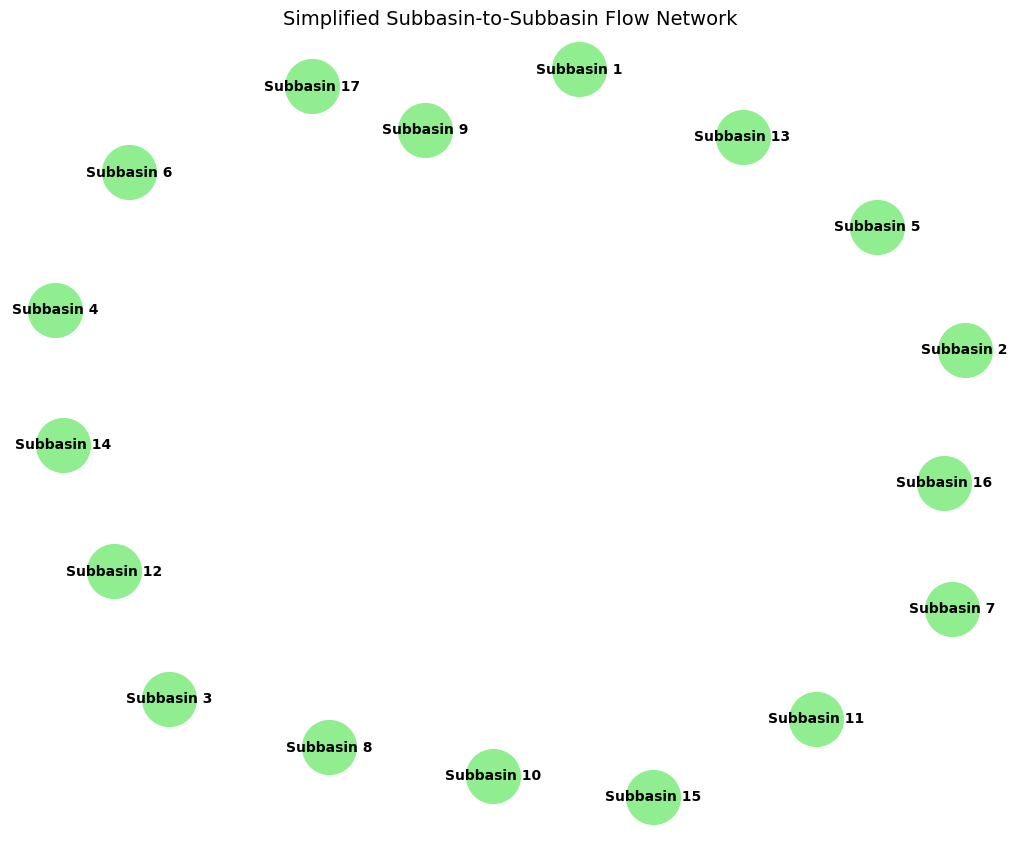

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

fig_path = fig_orig_path

# --- Parse ---
hyd_stor_to_subbasin = {}
routes = []
adds = []

with open(fig_path, 'r') as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i]
    if len(line) < 34:
        i += 1
        continue

    command = line[10:16].strip()

    if command == "1":  # SUBBASIN
        try:
            hyd_stor = int(line[16:22].strip())
            sub_num = int(line[22:28].strip())
            hyd_stor_to_subbasin[hyd_stor] = sub_num
            print(f"🟢 Subbasin {sub_num} uses HYD_STOR {hyd_stor}")
        except ValueError:
            print(f"⚠️ Failed parsing subbasin on line {i}")
        i += 2

    elif command == "2":  # ROUTE
        try:
            hyd_stor = int(line[16:22].strip())       # output
            inflow = int(line[28:34].strip())         # input
            routes.append((inflow, hyd_stor))
            print(f"🔷 ROUTE: {inflow} → {hyd_stor}")
        except ValueError:
            print(f"⚠️ Failed parsing ROUTE on line {i}")
        i += 2

    elif command == "5":  # ADD
        try:
            out = int(line[16:22].strip())
            in1 = int(line[22:28].strip())
            in2 = int(line[28:34].strip())
            adds.append((in1, in2, out))
            print(f"➕ ADD: {in1} + {in2} → {out}")
        except ValueError:
            print(f"⚠️ Failed parsing ADD on line {i}")
        i += 1
    else:
        i += 1

# --- Create Subbasin Flow Graph ---
G = nx.DiGraph()
subbasin_labels = {}

# Build mapping from HYD_STOR to subbasin
stor_to_sub = {v: k for k, v in hyd_stor_to_subbasin.items()}
sub_ids = set(hyd_stor_to_subbasin.values())

# Add nodes
for sub in sub_ids:
    G.add_node(sub)
    subbasin_labels[sub] = f"Subbasin {sub}"

# Add only ROUTE-based edges where both ends are in subbasins
for inflow, outflow in routes:
    if inflow in hyd_stor_to_subbasin and outflow in hyd_stor_to_subbasin:
        from_sub = hyd_stor_to_subbasin[inflow]
        to_sub = hyd_stor_to_subbasin[outflow]
        G.add_edge(from_sub, to_sub)
        print(f"➡️ Subbasin {from_sub} → Subbasin {to_sub}")
    else:
        print(f"🚫 ROUTE skipped: inflow {inflow}, outflow {outflow}")

# --- Plot ---
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

if G.number_of_edges() == 0:
    print("⚠️ No ROUTE connections between subbasins were found!")

nx.draw(G, pos, with_labels=True, labels=subbasin_labels, node_color='lightgreen',
        node_size=1500, font_size=10, font_weight='bold', arrows=True)
plt.title("Simplified Subbasin-to-Subbasin Flow Network", fontsize=14)
plt.grid(True)
plt.show()


🟢 Subbasin 1 uses HYD_STOR 1
🟢 Subbasin 2 uses HYD_STOR 2
🟢 Subbasin 3 uses HYD_STOR 3
🟢 Subbasin 4 uses HYD_STOR 4
🟢 Subbasin 5 uses HYD_STOR 5
🟢 Subbasin 6 uses HYD_STOR 6
🟢 Subbasin 7 uses HYD_STOR 7
🟢 Subbasin 8 uses HYD_STOR 8
🟢 Subbasin 9 uses HYD_STOR 9
🟢 Subbasin 10 uses HYD_STOR 10
🟢 Subbasin 11 uses HYD_STOR 11
🟢 Subbasin 12 uses HYD_STOR 12
🟢 Subbasin 13 uses HYD_STOR 13
🟢 Subbasin 14 uses HYD_STOR 14
🟢 Subbasin 15 uses HYD_STOR 15
🟢 Subbasin 16 uses HYD_STOR 16
🟢 Subbasin 17 uses HYD_STOR 17
🔷 ROUTE: 1 → 18
➕ ADD: 4 + 18 → 19
🔷 ROUTE: 19 → 20
🔷 ROUTE: 2 → 21
➕ ADD: 6 + 21 → 22
🔷 ROUTE: 22 → 23
🔷 ROUTE: 3 → 24
➕ ADD: 5 + 24 → 25
🔷 ROUTE: 25 → 26
🔷 ROUTE: 8 → 27
➕ ADD: 9 + 27 → 28
🔷 ROUTE: 28 → 29
🔷 ROUTE: 12 → 30
➕ ADD: 14 + 30 → 31
🔷 ROUTE: 31 → 32
🔷 ROUTE: 16 → 33
➕ ADD: 17 + 33 → 34
🔷 ROUTE: 34 → 35
➕ ADD: 7 + 20 → 36
➕ ADD: 36 + 26 → 37
➕ ADD: 37 + 29 → 38
🔷 ROUTE: 38 → 39
➕ ADD: 10 + 23 → 40
➕ ADD: 40 + 39 → 41
🔷 ROUTE: 41 → 42
➕ ADD: 11 + 42 → 43
🔷 ROUTE: 43 → 44
➕ ADD

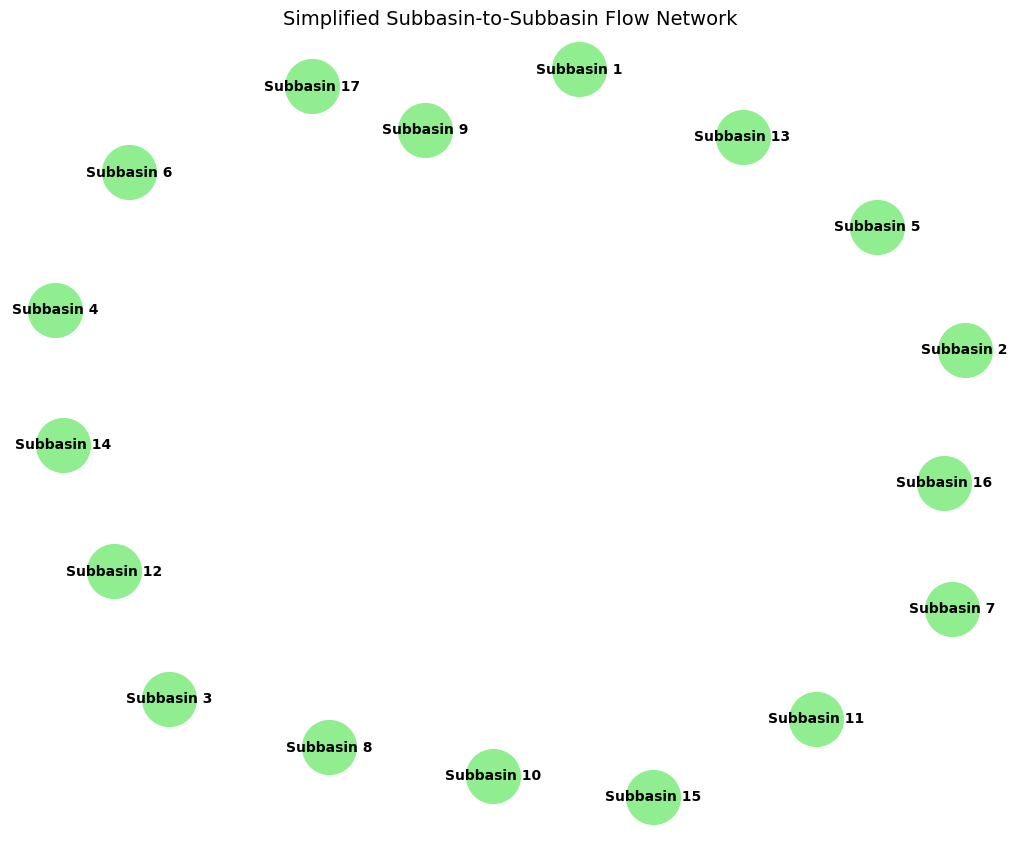

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

fig_path = fig_orig_path

# --- Parse ---
hyd_stor_to_subbasin = {}
routes = []
adds = []

with open(fig_path, 'r') as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i]
    if len(line) < 34:
        i += 1
        continue

    command = line[10:16].strip()

    if command == "1":  # SUBBASIN
        try:
            hyd_stor = int(line[16:22].strip())
            sub_num = int(line[22:28].strip())
            hyd_stor_to_subbasin[hyd_stor] = sub_num
            print(f"🟢 Subbasin {sub_num} uses HYD_STOR {hyd_stor}")
        except ValueError:
            print(f"⚠️ Failed parsing subbasin on line {i}")
        i += 2

    elif command == "2":  # ROUTE
        try:
            hyd_stor = int(line[16:22].strip())       # output
            inflow = int(line[28:34].strip())         # input
            routes.append((inflow, hyd_stor))
            print(f"🔷 ROUTE: {inflow} → {hyd_stor}")
        except ValueError:
            print(f"⚠️ Failed parsing ROUTE on line {i}")
        i += 2

    elif command == "5":  # ADD
        try:
            out = int(line[16:22].strip())
            in1 = int(line[22:28].strip())
            in2 = int(line[28:34].strip())
            adds.append((in1, in2, out))
            print(f"➕ ADD: {in1} + {in2} → {out}")
        except ValueError:
            print(f"⚠️ Failed parsing ADD on line {i}")
        i += 1
    else:
        i += 1

# Build input source mapping from ADD chains
from collections import defaultdict, deque

def trace_sources(hyd_stor, adds_map):
    visited = set()
    sources = set()
    queue = deque([hyd_stor])

    while queue:
        current = queue.popleft()
        if current in visited:
            continue
        visited.add(current)
        if current in adds_map:
            queue.extend(adds_map[current])
        else:
            sources.add(current)
    return sources

adds_map = defaultdict(list)
for in1, in2, out in adds:
    adds_map[out].extend([in1, in2])

# --- Create Subbasin Flow Graph ---
G = nx.DiGraph()
subbasin_labels = {}

# Add nodes
for sub in set(hyd_stor_to_subbasin.values()):
    G.add_node(sub)
    subbasin_labels[sub] = f"Subbasin {sub}"

# Trace ROUTE edges back to source subbasins
for inflow, outflow in routes:
    source_stors = trace_sources(inflow, adds_map)
    source_subs = {hyd_stor_to_subbasin[s] for s in source_stors if s in hyd_stor_to_subbasin}
    if outflow in hyd_stor_to_subbasin:
        target_sub = hyd_stor_to_subbasin[outflow]
        for src_sub in source_subs:
            G.add_edge(src_sub, target_sub)
            print(f"➡️ Subbasin {src_sub} → Subbasin {target_sub}")
    else:
        print(f"🚫 ROUTE target {outflow} not a subbasin")

# --- Plot ---
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

if G.number_of_edges() == 0:
    print("⚠️ No ROUTE connections between subbasins were found!")

nx.draw(G, pos, with_labels=True, labels=subbasin_labels, node_color='lightgreen',
        node_size=1500, font_size=10, font_weight='bold', arrows=True)
plt.title("Simplified Subbasin-to-Subbasin Flow Network", fontsize=14)
plt.grid(True)
plt.show()


## working parsing logic

In [ ]:
# Re-import and process the .fig file with more robust handling
fig_path = fig_orig_path
with open(fig_path, "r") as f:
    fig_lines = f.readlines()

# Extract subbasin, route, and add command blocks with safer parsing
subbasins, routes, adds = [], [], []
for i in range(len(fig_lines)):
    line = fig_lines[i]
    if line.strip().startswith("*"):  # Skip comments
        continue
    if line[10:16].strip() == "1":  # SUBBASIN
        cmd = {
            "COMMAND": int(line[10:16]),
            "HYD_STOR": int(line[16:22]),
            "SUB_NUM": int(line[22:28]),
            "GIS_CODE": line[46:55].strip() if len(line) >= 55 else None,
            "SUBFILE": fig_lines[i+1][10:23].strip()
        }
        subbasins.append(cmd)
    elif line[10:16].strip() == "2" and (i + 1 < len(fig_lines)):  # ROUTE
        try:
            cmd = {
                "COMMAND": int(line[10:16]),
                "HYD_STOR": int(line[16:22]),
                "RCH_NUM": int(line[22:28]),
                "HYD_NUM": int(line[28:34]),
                "FLOW_OVN": float(line[40:46].strip() or 0.0),
                "RTEFILE": fig_lines[i+1][10:23].strip(),
                "SWQFILE": fig_lines[i+1][23:36].strip()
            }
            routes.append(cmd)
        except ValueError:
            continue
    elif line[10:16].strip() == "5":  # ADD
        cmd = {
            "COMMAND": int(line[10:16]),
            "HYD_STOR": int(line[16:22]),
            "HYD_NUM1": int(line[22:28]),
            "HYD_NUM2": int(line[28:34])
        }
        adds.append(cmd)

(subbasins, routes, adds)

([{'COMMAND': 1,
   'HYD_STOR': 1,
   'SUB_NUM': 1,
   'GIS_CODE': '',
   'SUBFILE': '000010000.sub'},
  {'COMMAND': 1,
   'HYD_STOR': 2,
   'SUB_NUM': 2,
   'GIS_CODE': '',
   'SUBFILE': '000020000.sub'},
  {'COMMAND': 1,
   'HYD_STOR': 3,
   'SUB_NUM': 3,
   'GIS_CODE': '',
   'SUBFILE': '000030000.sub'},
  {'COMMAND': 1,
   'HYD_STOR': 4,
   'SUB_NUM': 4,
   'GIS_CODE': '',
   'SUBFILE': '000040000.sub'},
  {'COMMAND': 1,
   'HYD_STOR': 5,
   'SUB_NUM': 5,
   'GIS_CODE': '',
   'SUBFILE': '000050000.sub'},
  {'COMMAND': 1,
   'HYD_STOR': 6,
   'SUB_NUM': 6,
   'GIS_CODE': '',
   'SUBFILE': '000060000.sub'},
  {'COMMAND': 1,
   'HYD_STOR': 7,
   'SUB_NUM': 7,
   'GIS_CODE': '',
   'SUBFILE': '000070000.sub'},
  {'COMMAND': 1,
   'HYD_STOR': 8,
   'SUB_NUM': 8,
   'GIS_CODE': '',
   'SUBFILE': '000080000.sub'},
  {'COMMAND': 1,
   'HYD_STOR': 9,
   'SUB_NUM': 9,
   'GIS_CODE': '',
   'SUBFILE': '000090000.sub'},
  {'COMMAND': 1,
   'HYD_STOR': 10,
   'SUB_NUM': 10,
   'GIS_CODE': '',
